# Entrenamiento de Modelos — Forest Cover Type

In [1]:
import os
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from utils.model_trainer import ModelTrainer

## 1. Conexión a MySQL y carga de datos procesados

In [2]:
host = os.getenv('MYSQL_HOST', 'mysql')
port = os.getenv('MYSQL_PORT', '3306')
user = os.getenv('MYSQL_USER', 'user')
password = os.getenv('MYSQL_PASSWORD', 'user1234')
database = os.getenv('MYSQL_DATABASE', 'mydatabase')

engine = create_engine(f'mysql+mysqlconnector://{user}:{password}@{host}:{port}/{database}')

df = pd.read_sql('SELECT * FROM processed_forest_cover', engine)
engine.dispose()

print(f'Registros cargados: {len(df)}')
print(f'Columnas: {list(df.columns)}')
df.head()

/tmp/ipykernel_276/2490570456.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('SELECT * FROM processed_forest_cover', conn)


Registros cargados: 40670
Columnas: ['id', 'elevation', 'aspect', 'slope', 'horizontal_distance_to_hydrology', 'vertical_distance_to_hydrology', 'horizontal_distance_to_roadways', 'hillshade_9am', 'hillshade_noon', 'hillshade_3pm', 'horizontal_distance_to_fire_points', 'wilderness_area', 'soil_type', 'cover_type']


,id,elevation,aspect,slope,horizontal_distance_to_hydrology,vertical_distance_to_hydrology,horizontal_distance_to_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,horizontal_distance_to_fire_points,wilderness_area,soil_type,cover_type
0,1,2987,333,2,371,27,1951,214,236,160,967,comanche_peak,c19,2
1,2,3072,334,14,134,28,1651,187,221,172,3287,comanche_peak,c31,2
2,3,2360,298,19,67,17,283,163,230,205,808,cache_la_poudre,c10,3
3,4,3045,315,19,150,4,1915,165,220,194,3460,rawah,c22,1
4,5,3021,175,8,485,110,2571,225,245,153,1702,comanche_peak,c32,2


## 2. EDA

In [3]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nFilas duplicadas: {df.duplicated().sum()}')
print(f'\nDistribución de cover_type:\n{df["cover_type"].value_counts().sort_index()}')
print(f'\nWilderness areas: {df["wilderness_area"].unique()}')
print(f'Soil types: {sorted(df["soil_type"].unique())}')

Valores nulos por columna:
id                                    0
elevation                             0
aspect                                0
slope                                 0
horizontal_distance_to_hydrology      0
vertical_distance_to_hydrology        0
horizontal_distance_to_roadways       0
hillshade_9am                         0
hillshade_noon                        0
hillshade_3pm                         0
horizontal_distance_to_fire_points    0
wilderness_area                       0
soil_type                             0
cover_type                            0
dtype: int64

Filas duplicadas: 0

Distribución de cover_type:
cover_type
1    15357
2    17795
3     3401
4       28
5      714
6     2631
7      744
Name: count, dtype: int64

Wilderness areas: <StringArray>
['comanche_peak', 'cache_la_poudre', 'rawah']
Length: 3, dtype: str
Soil types: ['c1', 'c10', 'c11', 'c13', 'c14', 'c16', 'c17', 'c19', 'c2', 'c20', 'c22', 'c23', 'c24', 'c29', 'c3', 'c30', 'c31', 'c32',

## 3. Preparación de datos

In [4]:
# Eliminar columnas de metadatos
drop_cols = ['id', 'group_id', 'ingestion_ts']
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Codificar columnas categóricas
le_wilderness = LabelEncoder()
le_soil = LabelEncoder()
df_clean['wilderness_area'] = le_wilderness.fit_transform(df_clean['wilderness_area'])
df_clean['soil_type'] = le_soil.fit_transform(df_clean['soil_type'])

X = df_clean.drop('cover_type', axis=1)
y = df_clean['cover_type']

print(f'Features: {list(X.columns)}')
print(f'Clases: {sorted(y.unique())}')

Features: ['elevation', 'aspect', 'slope', 'horizontal_distance_to_hydrology', 'vertical_distance_to_hydrology', 'horizontal_distance_to_roadways', 'hillshade_9am', 'hillshade_noon', 'hillshade_3pm', 'horizontal_distance_to_fire_points', 'wilderness_area', 'soil_type']
Clases: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (32536, 12), Test: (8134, 12)


## 4. Inicializar ModelTrainer

In [6]:
trainer = ModelTrainer(
    models_dir='/app/models',
    report_path='/app/report/model_metrics.csv',
    minio_endpoint=os.getenv('MINIO_ENDPOINT', 'minio:9000'),
    minio_access_key=os.getenv('MINIO_ACCESS_KEY', 'minio_user'),
    minio_secret_key=os.getenv('MINIO_SECRET_KEY', 'minio1234'),
    minio_bucket='mlmodels',
)

## 5. Entrenar Random Forest


  randomforest — Classification Report
              precision    recall  f1-score   support

           1       0.98      0.95      0.97      3071
           2       0.95      0.98      0.96      3559
           3       0.96      0.96      0.96       680
           4       1.00      0.17      0.29         6
           5       0.98      0.72      0.83       143
           6       0.97      0.98      0.97       526
           7       0.97      0.98      0.97       149

    accuracy                           0.96      8134
   macro avg       0.97      0.82      0.85      8134
weighted avg       0.96      0.96      0.96      8134



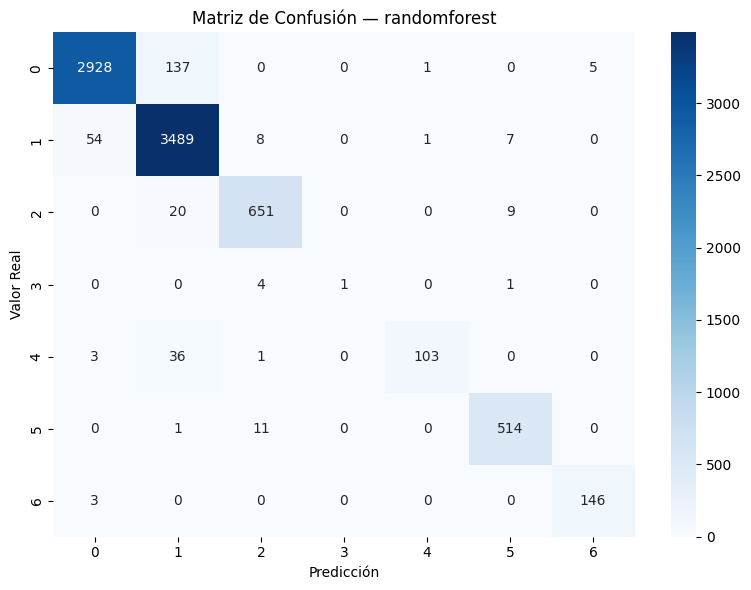


Pipeline 'randomforest' guardado en /app/models/randomforest_model.pkl
Pipeline subido a MinIO: s3://mlmodels/randomforest_model.pkl
Reporte actualizado en /app/report/model_metrics.csv


In [7]:
rf_metrics = trainer.train_and_save(
    name='randomforest',
    estimator=RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test,
    scaler=StandardScaler(),
)

## 6. Entrenar Gradient Boosting

In [ ]:
gb_metrics = trainer.train_and_save(
    name='gradientboosting',
    estimator=GradientBoostingClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42),
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test,
    scaler=StandardScaler(),
)

## 7. Entrenar SVM

In [ ]:
svm_metrics = trainer.train_and_save(
    name='svm',
    estimator=SVC(kernel='rbf', C=1.0, random_state=42),
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test,
    scaler=StandardScaler(),
)

## 8. Resumen de métricas

In [ ]:
report = pd.DataFrame([rf_metrics, gb_metrics, svm_metrics]).set_index('model')
print('Reporte guardado en /app/report/model_metrics.csv')
report